## 2) Cost Measurement on Tabular Data
We compare **communication** and **computation** costs on a tabular dataset, using
a neural model (MLP) vs a simpler model (Logistic Regression) vs a support vector machine model (SVM). 

**Runs used**:
- Adult LR (FL): `runs/adult_LR_fedavg`
- Adult MLP (FL): `runs/adult_MLP_fedavg`
- Adult SVM (FL): `runs/adult_SVM_fedavg`


### Imports

In [1]:
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

### Paths and load metrics

In [2]:
cwd = Path.cwd()
base = cwd / 'runs'

def load_global_metrics(run_path: Path) -> pd.DataFrame:
    global_csv = run_path / 'global_metrics.csv'
    metrics_csv = run_path / 'metrics.csv'
    if global_csv.exists():
        return pd.read_csv(global_csv)
    if metrics_csv.exists():
        return pd.read_csv(metrics_csv)
    raise FileNotFoundError(f'No global metrics CSV in {run_path}')

def load_comm_costs(run_path: Path):
    path = run_path / 'comm_costs.csv'
    return pd.read_csv(path) if path.exists() else None

def load_run_time(run_path: Path):
    path = run_path / 'run_metrics.csv'
    if not path.exists():
        return None
    df = pd.read_csv(path)
    row = df[df['metric'] == 'run_time_seconds']
    if row.empty:
        return None
    return float(row['value'].iloc[0])


def comm_to_mb(comm_df):
    if comm_df is None or comm_df.empty:
        return 0.0
    return (comm_df['comm_costs'].sum() * 4) / (1024**2)

def comm_to_kb(comm_df):
    if comm_df is None or comm_df.empty:
        return 0.0
    return (comm_df['comm_costs'].sum() * 4) / 1024



### Communication cost, training time and accuracy comparison 

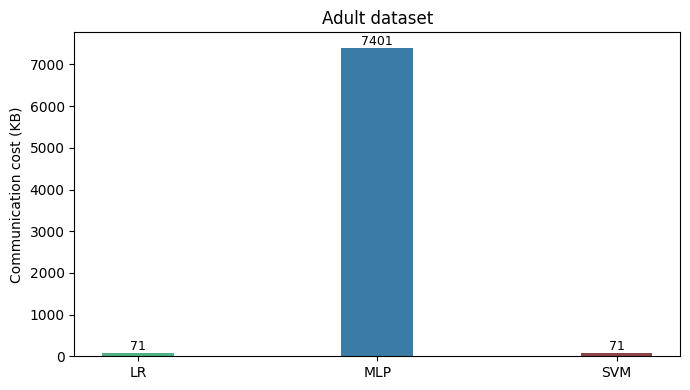

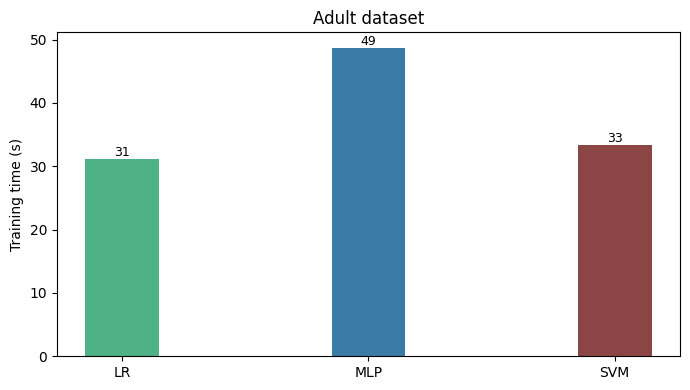

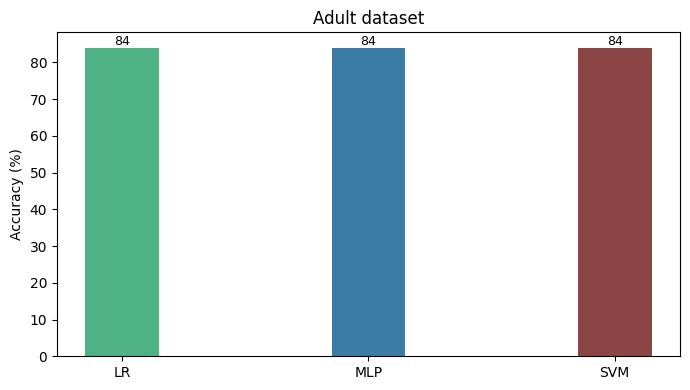

In [3]:
adult_lr_path = base / 'adult_LR_fedavg'
adult_mlp_path = base / 'adult_MLP_fedavg'
adult_svm_path = base / 'adult_SVM_fedavg'

adult_lr_metrics = load_global_metrics(adult_lr_path)
adult_mlp_metrics = load_global_metrics(adult_mlp_path)
adult_svm_metrics = load_global_metrics(adult_svm_path)

adult_lr_comm = comm_to_kb(load_comm_costs(adult_lr_path))
adult_mlp_comm = comm_to_kb(load_comm_costs(adult_mlp_path))
adult_svm_comm = comm_to_kb(load_comm_costs(adult_svm_path))

adult_lr_time = load_run_time(adult_lr_path) or 0
adult_mlp_time = load_run_time(adult_mlp_path) or 0
adult_svm_time = load_run_time(adult_svm_path) or 0

adult_lr_acc = float(adult_lr_metrics['accuracy'].iloc[-1]) * 100
adult_mlp_acc = float(adult_mlp_metrics['accuracy'].iloc[-1]) * 100
adult_svm_acc = float(adult_svm_metrics['accuracy'].iloc[-1]) * 100

labels = ['LR', 'MLP', 'SVM']
colors = ['#4FB286', '#3A7CA5', '#8C4545']

# Communication cost comparison
plt.figure(figsize=(7, 4))
bars = plt.bar(labels, [adult_lr_comm, adult_mlp_comm, adult_svm_comm], color=colors, width=0.3)
plt.title('Adult dataset')
plt.ylabel('Communication cost (KB)')
for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width() / 2, height, f'{height:.0f}', ha='center', va='bottom', fontsize=9)
plt.tight_layout()
plt.savefig("plots/adult_communication_comparison.png", dpi=300, bbox_inches='tight')
plt.show()


# Training time comparison
plt.figure(figsize=(7, 4))
bars = plt.bar(labels, [adult_lr_time, adult_mlp_time, adult_svm_time], color=colors, width=0.3)
plt.title('Adult dataset')
plt.ylabel('Training time (s)')
for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width() / 2, height, f'{height:.0f}', ha='center', va='bottom', fontsize=9)
plt.tight_layout()
plt.savefig("plots/adult_training_time_comparison.png", dpi=300, bbox_inches='tight')
plt.show()

# Accuracy comparison
plt.figure(figsize=(7, 4))
bars = plt.bar(labels, [adult_lr_acc, adult_mlp_acc, adult_svm_acc], color=colors, width=0.3)
plt.title('Adult dataset')
plt.ylabel('Accuracy (%)')
for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width() / 2, height, f'{height:.0f}', ha='center', va='bottom', fontsize=9)
plt.tight_layout()
plt.savefig("plots/adult_accuracy_comparison.png", dpi=300, bbox_inches='tight')
plt.show()





### Metrics of each model

- LogReg

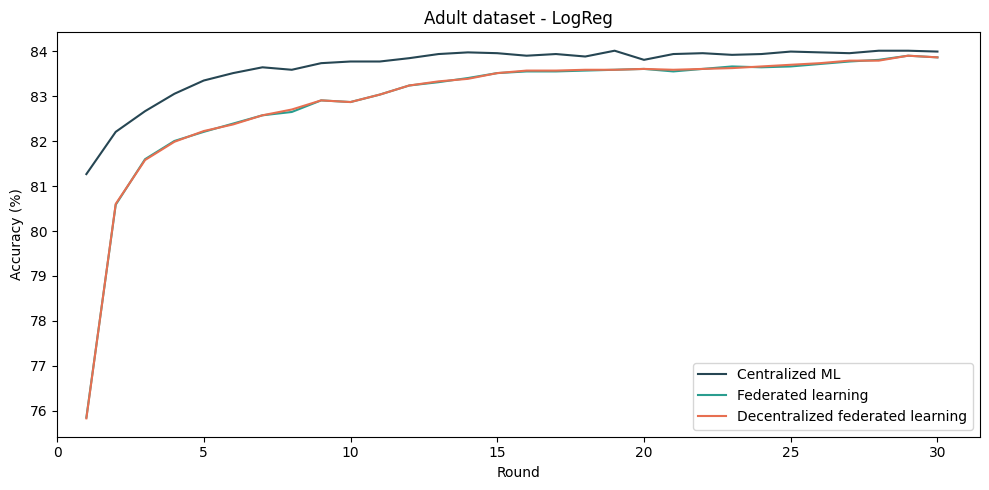

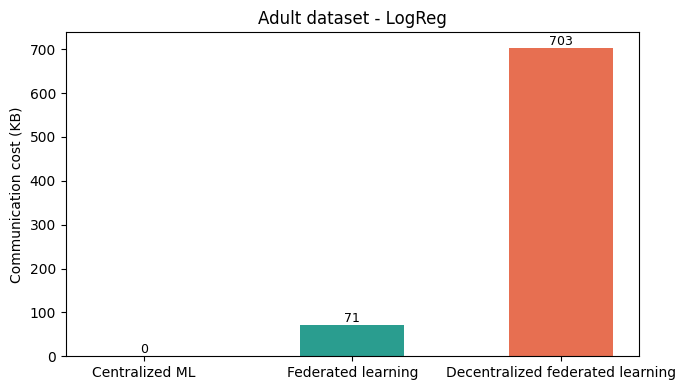

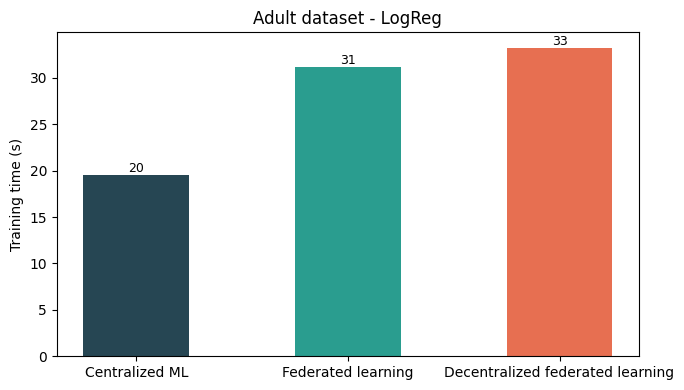

In [ ]:
adult_lr_paths = {
    'Centralized ML': base / 'adult_LR_centralized',
    'Federated learning': base / 'adult_LR_fedavg',
    'Decentralized federated learning': base / 'adult_LR_decentralized',
}

adult_lr_color_map = {
    'Centralized ML': '#264653',
    'Federated learning': '#2A9D8F',
    'Decentralized federated learning': '#E76F51',
}

adult_lr_metrics = {name: load_global_metrics(path) for name, path in adult_lr_paths.items()}

plt.figure(figsize=(10, 5))
for name, df in adult_lr_metrics.items():
    plt.plot(df['round'], df['accuracy'] * 100, label=name, color=adult_lr_color_map.get(name))
plt.title('Adult dataset - LogReg')
plt.xlabel('Round')
plt.ylabel('Accuracy (%)')
plt.xlim(left=0)
plt.legend()
plt.tight_layout()
plt.savefig('plots/adult_LR_centralized_vs_fl_vs_dec.png')
plt.show()

adult_lr_comm_totals = {name: comm_to_kb(load_comm_costs(path)) for name, path in adult_lr_paths.items()}
adult_lr_run_times = {name: load_run_time(path) or 0 for name, path in adult_lr_paths.items()}

labels = list(adult_lr_paths.keys())
colors = [adult_lr_color_map[l] for l in labels]

plt.figure(figsize=(7, 4))
bars = plt.bar(labels, [adult_lr_comm_totals[l] for l in labels], color=colors, width=0.5)
plt.title('Adult dataset - LogReg')
plt.ylabel('Communication cost (KB)')
for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width() / 2, height, f'{height:.0f}', ha='center', va='bottom', fontsize=9)
plt.tight_layout()
plt.savefig('plots/adult_LR_communication_cost.png')
plt.show()

plt.figure(figsize=(7, 4))
bars = plt.bar(labels, [adult_lr_run_times[l] for l in labels], color=colors, width=0.5)
plt.title('Adult dataset - LogReg')
plt.ylabel('Training time (s)')
for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width() / 2, height, f'{height:.0f}', ha='center', va='bottom', fontsize=9)
plt.tight_layout()
plt.savefig('plots/adult_LR_training_time.png')
plt.show()


- MLP

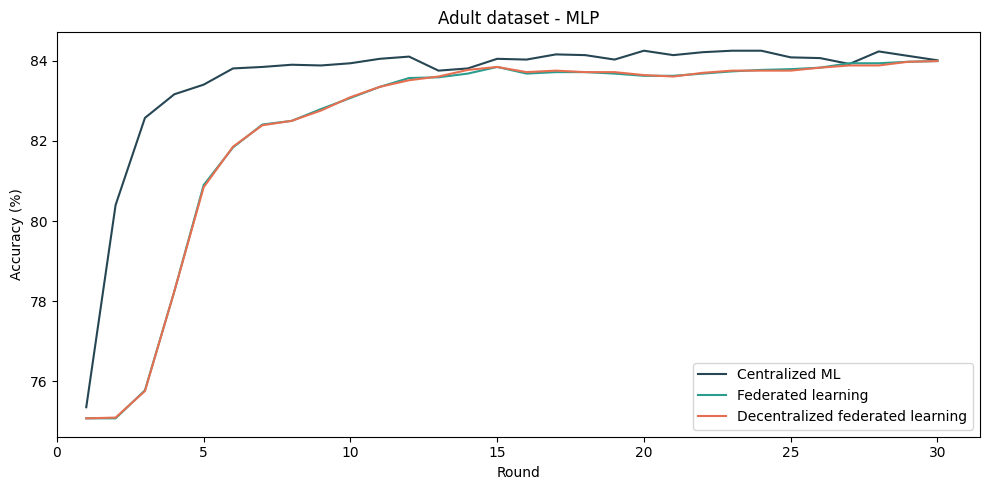

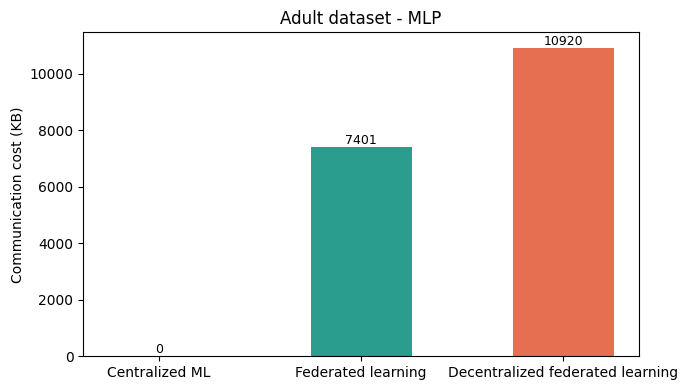

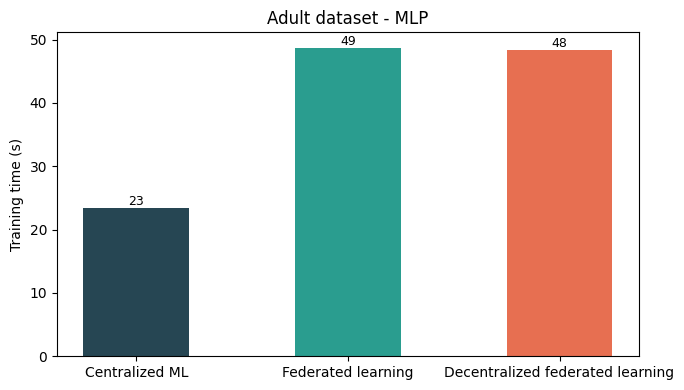

In [7]:
adult_MLP_paths = {
    'Centralized ML': base / 'adult_MLP_centralized',
    'Federated learning': base / 'adult_MLP_fedavg',
    'Decentralized federated learning': base / 'adult_MLP_decentralized',
}

adult_MLP_color_map = {
    'Centralized ML': '#264653',
    'Federated learning': '#2A9D8F',
    'Decentralized federated learning': '#E76F51',
}

adult_MLP_metrics = {name: load_global_metrics(path) for name, path in adult_MLP_paths.items()}

plt.figure(figsize=(10, 5))
for name, df in adult_MLP_metrics.items():
    plt.plot(df['round'], df['accuracy'] * 100, label=name, color=adult_MLP_color_map.get(name))
plt.title('Adult dataset - MLP')
plt.xlabel('Round')
plt.ylabel('Accuracy (%)')
plt.xlim(left=0)
plt.legend()
plt.tight_layout()
plt.savefig('plots/adult_MLP_centralized_vs_fl_vs_dec.png')
plt.show()

adult_MLP_comm_totals = {name: comm_to_kb(load_comm_costs(path)) for name, path in adult_MLP_paths.items()}
adult_MLP_run_times = {name: load_run_time(path) or 0 for name, path in adult_MLP_paths.items()}

labels = list(adult_MLP_paths.keys())
colors = [adult_MLP_color_map[l] for l in labels]

plt.figure(figsize=(7, 4))
bars = plt.bar(labels, [adult_MLP_comm_totals[l] for l in labels], color=colors, width=0.5)
plt.title('Adult dataset - MLP')
plt.ylabel('Communication cost (KB)')
for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width() / 2, height, f'{height:.0f}', ha='center', va='bottom', fontsize=9)
plt.tight_layout()
plt.savefig('plots/adult_MLP_communication_cost.png')
plt.show()

plt.figure(figsize=(7, 4))
bars = plt.bar(labels, [adult_MLP_run_times[l] for l in labels], color=colors, width=0.5)
plt.title('Adult dataset - MLP')
plt.ylabel('Training time (s)')
for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width() / 2, height, f'{height:.0f}', ha='center', va='bottom', fontsize=9)
plt.tight_layout()
plt.savefig('plots/adult_MLP_training_time.png')
plt.show()

- SVM

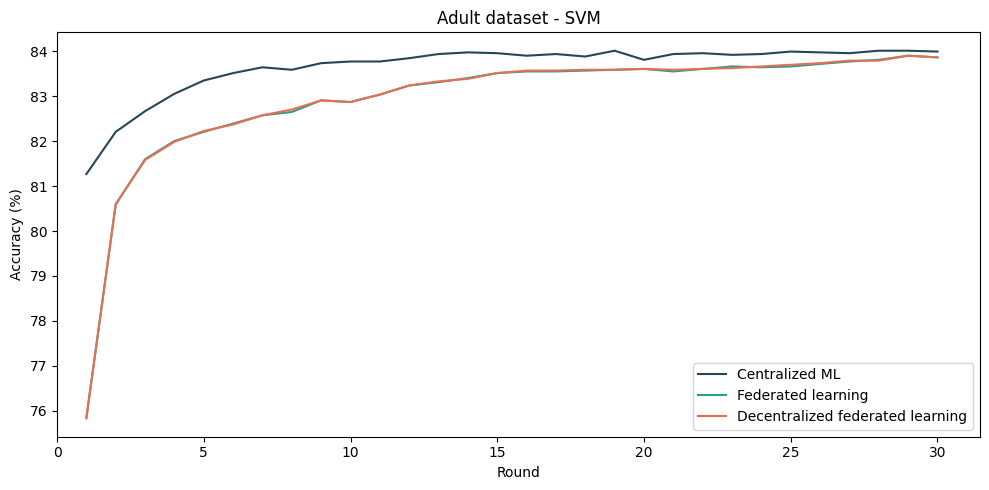

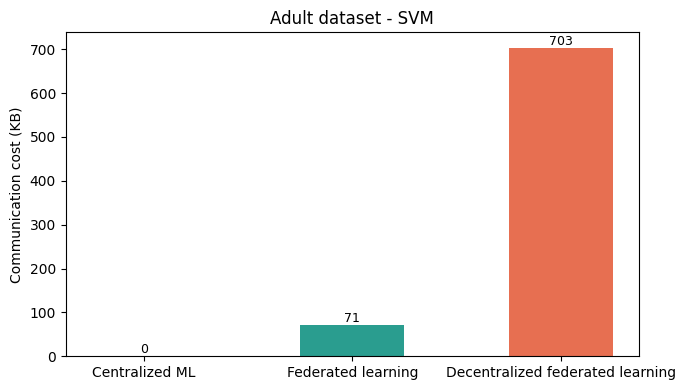

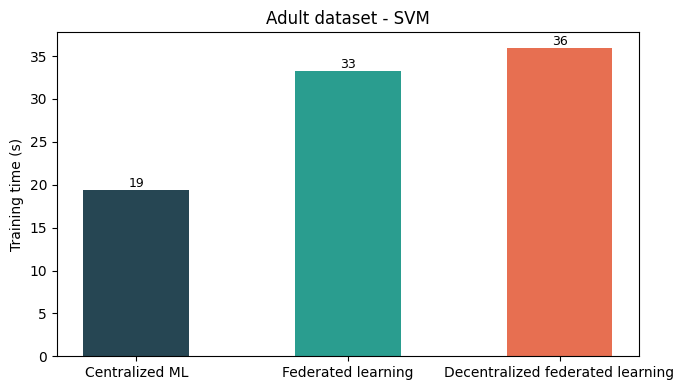

In [8]:
adult_SVM_paths = {
    'Centralized ML': base / 'adult_SVM_centralized',
    'Federated learning': base / 'adult_SVM_fedavg',
    'Decentralized federated learning': base / 'adult_SVM_decentralized',
}

adult_SVM_color_map = {
    'Centralized ML': '#264653',
    'Federated learning': '#2A9D8F',
    'Decentralized federated learning': '#E76F51',
}

adult_SVM_metrics = {name: load_global_metrics(path) for name, path in adult_SVM_paths.items()}

plt.figure(figsize=(10, 5))
for name, df in adult_SVM_metrics.items():
    plt.plot(df['round'], df['accuracy'] * 100, label=name, color=adult_SVM_color_map.get(name))
plt.title('Adult dataset - SVM')
plt.xlabel('Round')
plt.ylabel('Accuracy (%)')
plt.xlim(left=0)
plt.legend()
plt.tight_layout()
plt.savefig('plots/adult_SVM_centralized_vs_fl_vs_dec.png')
plt.show()

adult_SVM_comm_totals = {name: comm_to_kb(load_comm_costs(path)) for name, path in adult_SVM_paths.items()}
adult_SVM_run_times = {name: load_run_time(path) or 0 for name, path in adult_SVM_paths.items()}

labels = list(adult_SVM_paths.keys())
colors = [adult_SVM_color_map[l] for l in labels]

plt.figure(figsize=(7, 4))
bars = plt.bar(labels, [adult_SVM_comm_totals[l] for l in labels], color=colors, width=0.5)
plt.title('Adult dataset - SVM')
plt.ylabel('Communication cost (KB)')
for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width() / 2, height, f'{height:.0f}', ha='center', va='bottom', fontsize=9)
plt.tight_layout()
plt.savefig('plots/adult_SVM_communication_cost.png')
plt.show()

plt.figure(figsize=(7, 4))
bars = plt.bar(labels, [adult_SVM_run_times[l] for l in labels], color=colors, width=0.5)
plt.title('Adult dataset - SVM')
plt.ylabel('Training time (s)')
for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width() / 2, height, f'{height:.0f}', ha='center', va='bottom', fontsize=9)
plt.tight_layout()
plt.savefig('plots/adult_SVM_training_time.png')
plt.show()

### Cost‑to‑Accuracy  
We compute time‑to‑accuracy and communication‑to‑accuracy at 70/80/90/100% of the final accuracy.

### Adult LR vs Adult MLP vs Adult SVM

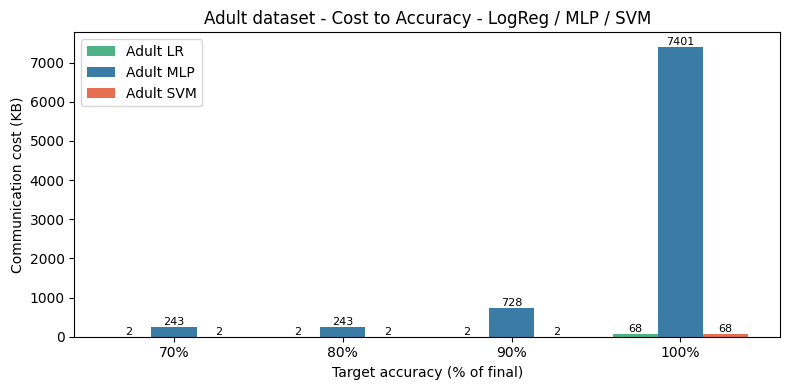

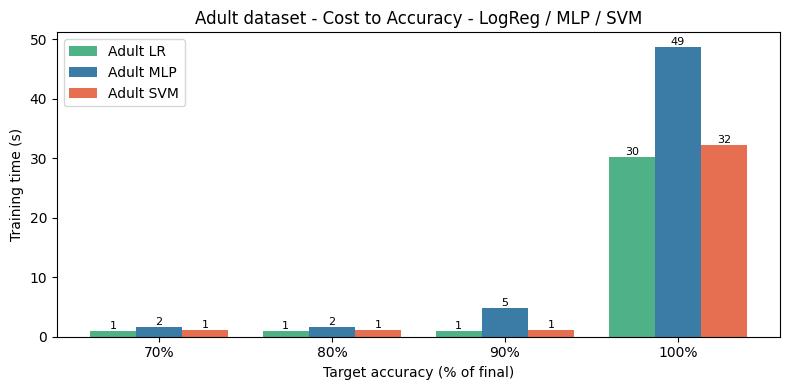

In [11]:
thresholds = [0.7, 0.8, 0.9, 1.0]
threshold_labels = ['70%', '80%', '90%', '100%']

def _comm_until(comm_df, target_round, unit='KB'):
    if comm_df is None or comm_df.empty:
        return 0
    total = comm_df[comm_df['round'] <= target_round]['comm_costs'].sum()
    bytes_per_param = 4
    if unit == 'KB':
        return (total * bytes_per_param) / 1024
    return (total * bytes_per_param) / (1024**2)

def compute_cost_to_accuracy(run_path, comm_unit='KB'):
    metrics_df = load_global_metrics(run_path)
    acc = metrics_df['accuracy'] * 100
    final_acc = float(acc.iloc[-1])
    round_vals = metrics_df['round'].astype(int)

    comm_df = load_comm_costs(run_path)
    run_time = load_run_time(run_path) or 0
    max_round = int(round_vals.max()) if len(round_vals) else 0
    time_per_round = (run_time / max_round) if max_round > 0 else 0

    comm_to_acc = []
    time_to_acc = []
    for t in thresholds:
        target = final_acc * t
        reached = round_vals[acc >= target]
        if reached.empty:
            comm_to_acc.append(float('nan'))
            time_to_acc.append(float('nan'))
            continue
        r = int(reached.iloc[0])
        comm_to_acc.append(_comm_until(comm_df, r, unit=comm_unit))
        time_to_acc.append(time_per_round * r)

    return comm_to_acc, time_to_acc

def plot_cost_to_accuracy(run_map, title, comm_unit='KB', colors=None, save_prefix=None):
    if colors is None:
        colors = ['#3A7CA5', '#4FB286']
    keys = list(run_map.keys())
    comm_data = []
    time_data = []
    for k in keys:
        comm_vals, time_vals = compute_cost_to_accuracy(run_map[k], comm_unit=comm_unit)
        comm_data.append(comm_vals)
        time_data.append(time_vals)

    x = range(len(thresholds))
    width = 0.8 / max(1, len(keys))

    plt.figure(figsize=(8, 4))
    for i, (k, vals) in enumerate(zip(keys, comm_data)):
        bars = plt.bar([xi + i * width for xi in x], vals, width=width, label=k, color=colors[i % len(colors)])
        for bar in bars:
            height = bar.get_height()
            if height == height:
                plt.text(bar.get_x() + bar.get_width() / 2, height, f'{height:.0f}', ha='center', va='bottom', fontsize=8)
    plt.title(title)
    plt.xlabel('Target accuracy (% of final)')
    plt.ylabel(f'Communication cost ({comm_unit})')
    plt.xticks([xi + width * (len(keys) - 1) / 2 for xi in x], threshold_labels)
    plt.legend()
    plt.tight_layout()
    if save_prefix:
        plt.savefig(f'{save_prefix}_comm.png')
    plt.show()

    plt.figure(figsize=(8, 4))
    for i, (k, vals) in enumerate(zip(keys, time_data)):
        bars = plt.bar([xi + i * width for xi in x], vals, width=width, label=k, color=colors[i % len(colors)])
        for bar in bars:
            height = bar.get_height()
            if height == height:
                plt.text(bar.get_x() + bar.get_width() / 2, height, f'{height:.0f}', ha='center', va='bottom', fontsize=8)
    plt.title(title)
    plt.xlabel('Target accuracy (% of final)')
    plt.ylabel('Training time (s)')
    plt.xticks([xi + width * (len(keys) - 1) / 2 for xi in x], threshold_labels)
    plt.legend()
    plt.tight_layout()
    if save_prefix:
        plt.savefig(f'{save_prefix}_time.png')
    plt.show()


adult_lr_path = base / 'adult_LR_fedavg'
adult_MLP_path = base / 'adult_MLP_fedavg'
adult_SVM_path = base / 'adult_SVM_fedavg'

adult_compare = {
    'Adult LR': adult_lr_path,
    'Adult MLP': adult_MLP_path,
    'Adult SVM': adult_SVM_path,
}
plot_cost_to_accuracy(adult_compare, 'Adult dataset - Cost to Accuracy - LogReg / MLP / SVM', comm_unit='KB', colors=['#4FB286', '#3A7CA5', '#E76F51'], save_prefix='plots/adult_cost_to_accuracy')
